In [1]:
# Data Preprocessing
# Load data
import pandas as pd
import numpy as np

books = pd.read_csv("Books.csv", encoding="latin-1", low_memory=False)
ratings = pd.read_csv("Ratings.csv")
users = pd.read_csv("Users.csv")

# Clean Data for Books and Ratings
books.drop(columns=["Image-URL-S", "Image-URL-M", "Image-URL-L"], inplace=True, errors="ignore")
books["Year-Of-Publication"] = pd.to_numeric(books["Year-Of-Publication"], errors="coerce")
books.fillna("", inplace=True)
books.drop_duplicates(inplace=True)

ratings = ratings.dropna()
ratings = ratings[ratings["Book-Rating"] >= 0]

# Merge
data = ratings.merge(books, on="ISBN").merge(users, on="User-ID")

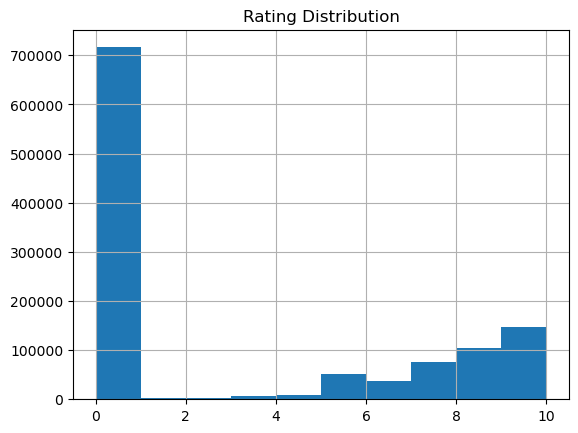

Top Popular Books:
 Book-Title
Wild Animus                                        2502
The Lovely Bones: A Novel                          1295
The Da Vinci Code                                   898
A Painted House                                     838
The Nanny Diaries: A Novel                          828
Bridget Jones's Diary                               815
The Secret Life of Bees                             774
Divine Secrets of the Ya-Ya Sisterhood: A Novel     740
The Red Tent (Bestselling Backlist)                 723
Angels &amp; Demons                                 670
Name: Book-Rating, dtype: int64


In [2]:
# Explorating Data Analysis
import matplotlib.pyplot as plt

# Ratings distribution
ratings['Book-Rating'].hist()
plt.title("Rating Distribution")
plt.show()

# Most popular books
popular = data.groupby("Book-Title")["Book-Rating"].count().sort_values(ascending=False).head(10)
print("Top Popular Books:\n", popular)

In [3]:
# Collaborative Filtering
# Filter users
active_users = data.groupby("User-ID")["Book-Rating"].count()
data = data[data["User-ID"].isin(active_users[active_users > 50].index)]

# Filter books
popular_books = data.groupby("ISBN")["Book-Rating"].count()
data = data[data["ISBN"].isin(popular_books[popular_books > 50].index)]

# Create matrix
user_item_matrix = data.pivot_table(
    index='User-ID',
    columns='ISBN',
    values='Book-Rating'
).fillna(0)

print("Matrix Shape:", user_item_matrix.shape)

Matrix Shape: (2908, 1040)


In [4]:
from sklearn.neighbors import NearestNeighbors

model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(user_item_matrix.T)

NearestNeighbors(algorithm='brute', metric='cosine')

In [5]:
# Book Recommendation Function
def recommend_books(isbn, top_n=5):
    if isbn not in user_item_matrix.columns:
        return "Book not found"

    idx = list(user_item_matrix.columns).index(isbn)

    distances, indices = model_knn.kneighbors(
        user_item_matrix.T.iloc[idx].values.reshape(1, -1),
        n_neighbors=top_n + 1
    )

    similar_books = user_item_matrix.columns[indices.flatten()[1:]]

    return books[books["ISBN"].isin(similar_books)][["Book-Title", "Book-Author"]]
recommend_books('002542730X')

,Book-Title,Book-Author
926,The Diary of Ellen Rimbauer: My Life at Rose Red,Ellen Rimbauer
2517,Don't Stand Too Close to a Naked Man,Tim Allen
4665,The Reptile Room (A Series of Unfortunate Even...,Lemony Snicket
10714,The Hundred Secret Senses,Amy Tan
10969,The Genesis Code,John Case


In [21]:
# Content-based Filtering
# Sample dataset to reduce memory usage
books_sample = books.sample(10000, random_state=42).reset_index(drop=True)

# Create content column
books_sample["content"] = (
    books_sample["Book-Title"].astype(str) + " " +
    books_sample["Book-Author"].astype(str) + " " +
    books_sample["Publisher"].astype(str)
)

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=3000
)

tfidf_matrix = tfidf.fit_transform(books_sample["content"])

# Similarity
from sklearn.metrics.pairwise import cosine_similarity

def content_recommend(title, top_n=5):

    # Check existence
    if title not in books_sample["Book-Title"].values:
        return "Book not found in sampled dataset"

    # Get correct index FROM books_sample
    idx = books_sample[books_sample["Book-Title"] == title].index[0]

    # Compute similarity
    sim_scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()

    # Get top similar indices
    sim_indices = sim_scores.argsort()[-(top_n + 1):][::-1][1:]

    # Return recommendations
    recommendations = books_sample.iloc[sim_indices][[
        "Book-Title",
        "Book-Author",
        "Publisher",
        "Year-Of-Publication"
    ]]

    return recommendations.reset_index(drop=True)

content_recommend('Sky Knife')

,Book-Title,Book-Author,Publisher,Year-Of-Publication
0,The Burning Sky,Ron Faust,Tor Books,1995.0
1,Wind from a Foreign Sky (The Tielmaran Chronic...,Katya Reimann,Tor Books,1997.0
2,The Yngling,John Dalmas,Tor Books,1984.0
3,Appleseed,John Clute,Tor Books,2002.0
4,Xanadu,Jane Yolen,Tor Books,1994.0


In [23]:
corr_matrix = user_item_matrix.corr(method="pearson")

def correlation_recommend(isbn, top_n=5):
    if isbn not in corr_matrix.columns:
        return "Book not found"

    similar = corr_matrix[isbn].sort_values(ascending=False)[1:top_n+1]

    return books[books["ISBN"].isin(similar.index)][["Book-Title", "Book-Author"]]
correlation_recommend('0060008032')

,Book-Title,Book-Author
1216,The Beekeeper's Apprentice,LAURIE R. KING
7546,Girl in Hyacinth Blue,Susan Vreeland
8807,Quentins,Maeve Binchy
10643,Fine Things,Danielle Steel
31115,Personal Injuries,Scott Turow


In [8]:
# Decision Tree Model
from sklearn.preprocessing import LabelEncoder

user_enc = LabelEncoder()
book_enc = LabelEncoder()

data['user_encoded'] = user_enc.fit_transform(data['User-ID'])
data['book_encoded'] = book_enc.fit_transform(data['ISBN'])

X = data[['user_encoded', 'book_encoded']]
y = data['Book-Rating']

from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(X, y)

DecisionTreeRegressor()

In [9]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50)
matrix_reduced = svd.fit_transform(user_item_matrix)

print("SVD shape:", matrix_reduced.shape)

SVD shape: (2908, 50)


In [35]:
# ITEM-BASED MODEL
item_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

item_model.fit(user_item_matrix.T)

NearestNeighbors(algorithm='brute', metric='cosine')

In [36]:
# USER-BASED MODEL
user_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

user_model.fit(user_item_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [42]:
# Mapping
isbn_to_idx = pd.Series(
    books_sample.index,
    index=books_sample["ISBN"]
).drop_duplicates()


def hybrid_recommend(user_id, top_n=5, alpha=0.7):

    # Ensure integer
    user_id = int(user_id)

    # Check user
    if user_id not in user_item_matrix.index:
        return "User not found"

    # ==================================
    # COLLABORATIVE FILTERING PART
    # ==================================

    user_vector = user_item_matrix.loc[[user_id]]

    distances, indices = user_model.kneighbors(
        user_vector,
        n_neighbors=6
    )

    similar_users = user_item_matrix.index[
        indices.flatten()[1:]
    ]

    cf_scores = user_item_matrix.loc[
        similar_users
    ].mean(axis=0)

    # ==================================
    # CONTENT-BASED PART
    # ==================================

    liked_books = user_item_matrix.loc[user_id]
    liked_books = liked_books[liked_books > 0].index

    content_scores = np.zeros(len(books_sample))

    for isbn in liked_books:

        if isbn in isbn_to_idx:

            idx = isbn_to_idx[isbn]

            sim = cosine_similarity(
                tfidf_matrix[idx],
                tfidf_matrix
            ).flatten()

            content_scores += sim

    # Normalize
    if len(liked_books) > 0:
        content_scores /= len(liked_books)

    content_scores = pd.Series(
        content_scores,
        index=books_sample["ISBN"]
    )

    # ==================================
    # HYBRID COMBINATION
    # ==================================

    final_scores = (
        alpha * cf_scores.reindex(
            content_scores.index
        ).fillna(0)
        +
        (1 - alpha) * content_scores
    )

    # Remove already read books
    final_scores = final_scores.drop(
        liked_books,
        errors="ignore"
    )

    # Top recommendations
    top_books = final_scores.sort_values(
        ascending=False
    ).head(top_n)

    # Final output
    results = books_sample[
        books_sample["ISBN"].isin(top_books.index)
    ][[
        "ISBN",
        "Book-Title",
        "Book-Author",
        "Publisher",
        "Year-Of-Publication"
    ]].copy()

    results["Hybrid Score"] = results["ISBN"].map(top_books)

    return results.sort_values(
        by="Hybrid Score",
        ascending=False
    ).reset_index(drop=True)

hybrid_recommend(507)

,ISBN,Book-Title,Book-Author,Publisher,Year-Of-Publication,Hybrid Score
0,0804114986,The Bonesetter's Daughter,Amy Tan,Ballantine Books,2002.0,0.98
1,0679764275,The F Word,Jesse Sheidlower,Random House Reference Publishing,1995.0,0.00
2,1576732398,The Prayer Tree,Annie Jones,Alabaster,1998.0,0.00
3,155369015X,Scarab-4,S. Roy L. Hawkins,Not Avail,2001.0,0.00
4,0451516125,Three Eighteenth Century Novels,Daniel Defoe,New American Library,1982.0,0.00


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

train, test = train_test_split(data, test_size=0.2, random_state=42)

# Simple baseline: mean rating
y_true = test["Book-Rating"]
y_pred = np.full(len(y_true), train["Book-Rating"].mean())

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("RMSE:", rmse)

RMSE: 3.731832963170041
